# Project T: Classification of Real vs. Fake Faces using ResNet-18

**Group Name:** IowaGPT  
**Members:** Amit Boodhoo, Diego Liogon, Eva Singh, Kate Meyer

This notebook contains the training, validation, and test workflow required for Project T. It uses transfer learning with a pretrained ResNet-18 model to classify face images as `fake` or `real`.

Project requirements covered here:

- Advanced/modern technique: PyTorch transfer learning with ResNet-18.
- Training and validation steps.
- Final held-out test evaluation with accuracy, confusion matrix, classification report, and ROC AUC.
- Saved model file for the separate demo notebook.

Dataset: Kaggle `xhlulu/140k-real-and-fake-faces`.

Credits: This project follows the transfer-learning pattern from the class tutorial and the PyTorch transfer learning tutorial, adapted to the real-vs-fake face dataset.

In [1]:
# If running in a new VS Code, Jupyter, or Colab environment, uncomment this cell first.
#%pip install torch torchvision kagglehub matplotlib pandas scikit-learn pillow

In [ ]:
# Step 1: Environment Setup and Imports
import os
# Fix for potential library conflicts on some systems
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, models, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# Set random seed to ensure results are the same every time the code runs
SEED = 3110
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Define file paths and basic training settings
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "Project_T_Train.ipynb").exists() and (PROJECT_DIR / "Project_T" / "Project_T_Train.ipynb").exists():
    PROJECT_DIR = PROJECT_DIR / "Project_T"
MODEL_PATH = PROJECT_DIR / "resnet18_fake_faces.pt"
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 1e-3
NUM_WORKERS = 0  # 0 is safest on Windows/macOS notebooks.

# Set to None to use the full dataset. A balanced subset keeps training practical on laptops.
MAX_IMAGES_PER_CLASS = None

# Automatically pick the best available hardware
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [ ]:
# Step 2: Download Dataset
import kagglehub

print("Downloading or locating Kaggle dataset...")
dataset_path = Path(kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces"))
base_dir = dataset_path / "real_vs_fake" / "real-vs-fake"

print(f"Dataset path: {dataset_path}")
print(f"Expected image root: {base_dir}")

if not base_dir.exists():
    raise FileNotFoundError(f"Could not find expected dataset folder: {base_dir}")

print("Available folders:", [p.name for p in sorted(base_dir.iterdir()) if p.is_dir()])

Dataset path: /Users/dglio/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2
Expected image root: /Users/dglio/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake
Available folders: ['test', 'train', 'valid']


## 1. Data Preprocessing & Augmentation  
To reduce overfitting, we use data augmentation so the model doesn’t just memorize the training images. We apply `RandomHorizontalFlip(p=0.5)` to create more variation in the faces. All images are resized to 224×224 and normalized to match the format used by ResNet-18.

In [ ]:
# Step 3: Data Preparation and Augmentation

# Transformations for training. Resize, flip images randomly, and normalize colors
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Transformations for testing/validation. Resize and normalize (no random flips)
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Helper function to get class labels from different types of PyTorch datasets
def dataset_targets(dataset):
    # ImageFolder has .targets; Subset wraps another dataset and stores .indices.
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    if isinstance(dataset, Subset):
        base_targets = dataset_targets(dataset.dataset)
        return base_targets[np.array(dataset.indices)]
    raise TypeError(f"Cannot infer labels for dataset type: {type(dataset)}")

# Helper function to create a smaller, balanced version of the dataset if needed
def balanced_subset(dataset, max_per_class=None, seed=SEED):
    # Return a balanced subset with up to max_per_class examples per class.
    if max_per_class is None:
        return dataset

    rng = random.Random(seed)
    labels = dataset_targets(dataset)
    selected = []
    for class_idx in sorted(set(labels.tolist())):
        indices = np.where(labels == class_idx)[0].tolist()
        rng.shuffle(indices)
        selected.extend(indices[:max_per_class])

    rng.shuffle(selected)
    return Subset(dataset, selected)

# Load a specific folder (train, valid, test)
def load_dataset_split(split_name, transform):
    split_dir = base_dir / split_name
    if not split_dir.exists():
        return None
    return datasets.ImageFolder(root=split_dir, transform=transform)

# Load the full datasets
train_dataset_full = load_dataset_split("train", train_transform)
valid_dataset_full = load_dataset_split("valid", eval_transform)
test_dataset_full = load_dataset_split("test", eval_transform)

# Fallback: if validation/test folders are missing, split the training folder manually
if train_dataset_full is None:
    raise FileNotFoundError("The Kaggle dataset did not contain a train split.")

# Prefer the dataset's official train/valid/test folders. If valid/test are missing, create them from train.
if valid_dataset_full is None or test_dataset_full is None:
    print("Official valid/test folders not found. Creating 70/15/15 split from the train folder.")
    full_eval_dataset = datasets.ImageFolder(root=base_dir / "train", transform=eval_transform)
    train_size = int(0.70 * len(full_eval_dataset))
    valid_size = int(0.15 * len(full_eval_dataset))
    test_size = len(full_eval_dataset) - train_size - valid_size
    train_indices, valid_indices, test_indices = random_split(
        range(len(full_eval_dataset)),
        [train_size, valid_size, test_size],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_dataset_full = Subset(datasets.ImageFolder(root=base_dir / "train", transform=train_transform), list(train_indices))
    valid_dataset_full = Subset(full_eval_dataset, list(valid_indices))
    test_dataset_full = Subset(full_eval_dataset, list(test_indices))
    class_names = full_eval_dataset.classes
else:
    class_names = train_dataset_full.classes

# Apply balancing (if MAX_IMAGES_PER_CLASS is set)
train_dataset = balanced_subset(train_dataset_full, MAX_IMAGES_PER_CLASS)
valid_dataset = balanced_subset(valid_dataset_full, max(1, MAX_IMAGES_PER_CLASS // 4) if MAX_IMAGES_PER_CLASS else None)
test_dataset = balanced_subset(test_dataset_full, max(1, MAX_IMAGES_PER_CLASS // 4) if MAX_IMAGES_PER_CLASS else None)

# Create DataLoaders to feed images into the model in batches
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

dataloaders = {"train": train_loader, "valid": valid_loader, "test": test_loader}
dataset_sizes = {"train": len(train_dataset), "valid": len(valid_dataset), "test": len(test_dataset)}

print("Class names:", class_names)
print("Class-to-index mapping:", getattr(train_dataset_full, "class_to_idx", "see wrapped dataset"))
print("Dataset sizes:", dataset_sizes)

Class names: ['fake', 'real']
Class-to-index mapping: {'fake': 0, 'real': 1}
Dataset sizes: {'train': 100000, 'valid': 20000, 'test': 20000}


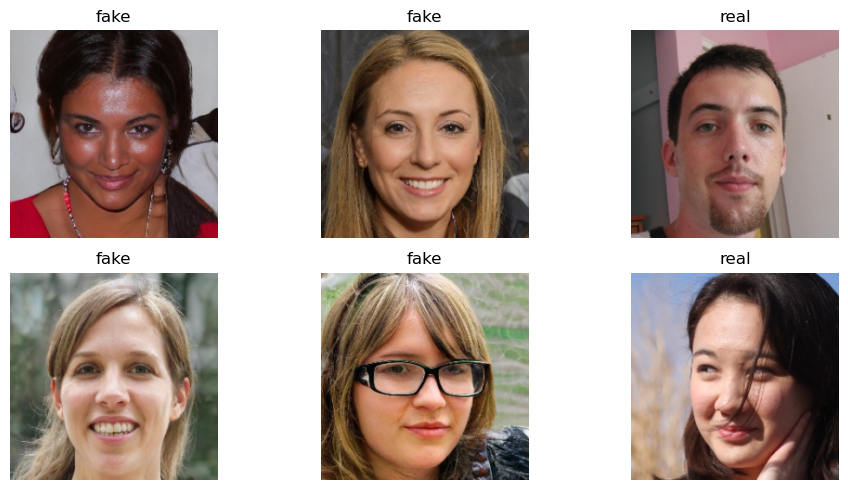

In [ ]:
# Function to convert a PyTorch tensor back into a viewable image
def imshow_tensor(tensor_image, title=None):
    # Convert from (Channels, Height, Width) to (Height, Width, Channels) for plotting
    image = tensor_image.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # Reverse the normalization: multiply by std and add the mean
    # clip(0, 1) ensures all pixel values stay within the valid 0 to 1 range
    image = np.clip(std * image + mean, 0, 1)
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)

# Grab one batch of images and labels from the training data
inputs, labels = next(iter(train_loader))
# Set up a figure window to display the images
plt.figure(figsize=(10, 5))
# Loop through the first 6 images in the batch
for i in range(min(6, len(inputs))):
    plt.subplot(2, 3, i + 1)
    # Use the function above to show the image with its corresponding class name
    imshow_tensor(inputs[i].cpu(), class_names[int(labels[i].item())])
plt.tight_layout()
plt.show()

## 2. Model Setup: Transfer Learning with ResNet-18  
Instead of training from scratch, we use transfer learning. We load a pre-trained ResNet-18 model and freeze its main layers (`param.requires_grad = False`) so their learned features stay the same. Then we only train the final layer (`model.fc`) to classify two classes: Real vs. Fake.

In [ ]:
# Load the ResNet-18 model with its "pre-trained" knowledge from ImageNet
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Freeze pretrained feature layers and train only the final classifier layer.
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

# Define the "Loss Function" to measure how wrong the model's guesses are
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

# Print the structure of the new final layer to verify the output size
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


## 3. The Training Loop
Here we train the final layer of our model. We track both the training loss/accuracy and the validation loss/accuracy across our epochs. To ensure we save the best possible version of our model, we track the highest validation accuracy and use `copy.deepcopy` to save those specific weights.

In [ ]:
# Helper function to process all images in the dataset exactly once
def run_one_epoch(model, loader, phase):
    if phase == "train":
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == "train"):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            if phase == "train":
                loss.backward()
                optimizer.step()
        # Keep track of statistics for the entire epoch
        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        running_correct += torch.sum(preds == labels).item()
        total += batch_size

    # Return average loss and accuracy for this pass
    return running_loss / total, running_correct / total

# Initialize variables to keep track of the best version of the model
best_model_weights = copy.deepcopy(model.state_dict())
best_valid_acc = 0.0
history = []
start_time = time.time()

# Main training loop: repeat for the number of EPOCHS defined earlier
for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 20)

    train_loss, train_acc = run_one_epoch(model, train_loader, "train")
    valid_loss, valid_acc = run_one_epoch(model, valid_loader, "valid")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    print(f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f}")
    print(f"valid loss: {valid_loss:.4f} | valid acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_weights = copy.deepcopy(model.state_dict())

elapsed = time.time() - start_time
print(f"Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
print(f"Best validation accuracy: {best_valid_acc:.4f}")

# Revert the model to the "best" version found during the process
model.load_state_dict(best_model_weights)
pd.DataFrame(history)

Epoch 1/3
--------------------
train loss: 0.4683 | train acc: 0.7791
valid loss: 0.4343 | valid acc: 0.7961
Epoch 2/3
--------------------
train loss: 0.4446 | train acc: 0.7925
valid loss: 0.4758 | valid acc: 0.7743
Epoch 3/3
--------------------
train loss: 0.4420 | train acc: 0.7952
valid loss: 0.4293 | valid acc: 0.8041
Training complete in 25m 53s
Best validation accuracy: 0.8041


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,0.468329,0.77905,0.434284,0.79610
1,2,0.444623,0.79250,0.475781,0.77430
2,3,0.442013,0.79524,0.429267,0.80405


## 4. Held-out Test Set Evaluation
Once training is complete, we evaluate the best model on a completely unseen test dataset. We generate a Classification Report to view our Precision and Recall, plot a Confusion Matrix to see exactly where the model gets confused, and calculate the ROC AUC score to measure its overall classification performance.

Test accuracy: 0.8018
              precision    recall  f1-score   support

        fake       0.83      0.75      0.79     10000
        real       0.78      0.85      0.81     10000

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000



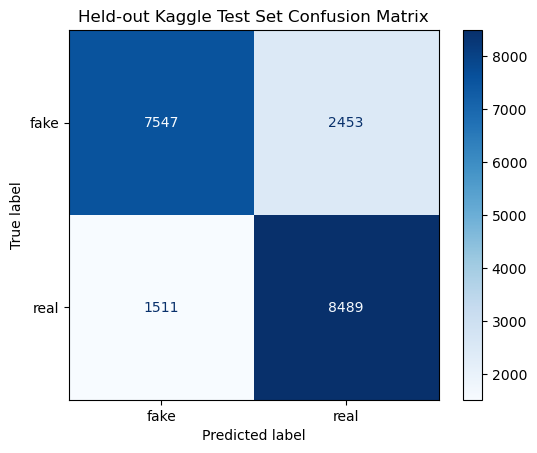

ROC AUC for class 'real': 0.8877


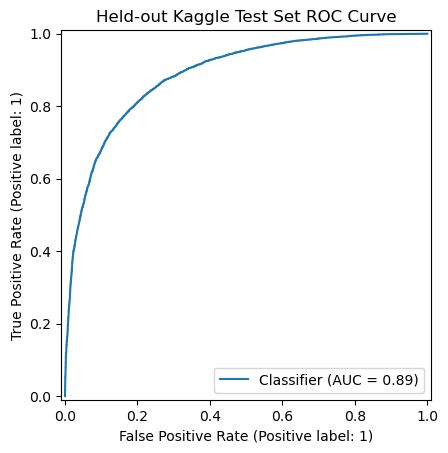

In [ ]:
# Function to gather all model predictions for a specific dataset (like the test set)
def collect_predictions(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    # Disable gradient calculations to save memory and speed up the process
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions for the final "held-out" test set
y_true, y_pred, y_prob = collect_predictions(model, test_loader)
test_acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

# Create and display a Confusion Matrix to see which classes are being mixed up
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Held-out Kaggle Test Set Confusion Matrix")
plt.show()

# If it's a binary classification (Real vs Fake), calculate and plot the ROC curve
if len(class_names) == 2:
    positive_idx = class_names.index("real") if "real" in class_names else 1
    auc = roc_auc_score(y_true, y_prob[:, positive_idx])
    print(f"ROC AUC for class '{class_names[positive_idx]}': {auc:.4f}")
    RocCurveDisplay.from_predictions(y_true, y_prob[:, positive_idx], pos_label=positive_idx)
    plt.title("Held-out Kaggle Test Set ROC Curve")
    plt.show()
else:
    auc = None

## 5. Saving the Model Checkpoint
Finally, we save the model's state. Rather than just saving the weights, we save a comprehensive dictionary containing the `class_names`, `image_size`, and validation accuracy. This ensures our separate Demo Notebook can load the exact required environment dynamically.

In [ ]:
# Create a dictionary (checkpoint) to bundle the model weights and important metadata
# This makes it easier to load the model later for a demo or app without re-training
checkpoint = {
    "model_name": "resnet18",
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "model_state_dict": model.state_dict(),
    "best_valid_acc": best_valid_acc,
    "test_acc": test_acc,
    "roc_auc": auc,
    "history": history,
    "dataset": "xhlulu/140k-real-and-fake-faces",
    "max_images_per_class": MAX_IMAGES_PER_CLASS,
}

# Save the checkpoint dictionary to a file on your hard drive
torch.save(checkpoint, MODEL_PATH)
# Confirm the file was saved and display its size in Megabytes
print(f"Saved trained model checkpoint to: {MODEL_PATH}")
print(f"Saved file size: {MODEL_PATH.stat().st_size / (1024 * 1024):.2f} MB")

Saved trained model checkpoint to: /Users/dglio/Documents/courses/AIML/AIML2026Projects/Project_T/resnet18_fake_faces.pt
Saved file size: 42.72 MB
